## from Pei PRL (2026)

$$ M\dot v = -f(v(t))+\sqrt{B(v(t))}\xi(t)\\
-{1\over M}G(v(t)) +{1-\eta\over M}B'(v(t))
$$

(main eq.5)

where
$$ f(v) = N\left<F(r)\right>_v\\
B(v) = N\int_0^\infty ds\left< F(r(s));F(r(0)) \right>_v\\
G(v) = N\int_0^\infty ds\left< F(r(s));F(r(0))\partial_v \ln{\pi_v(r(0))} \right>_v
$$

response theory (near v~0) -> f(0)=0, B'(0)=0
$$ M\dot v = -\gamma v+\sqrt{B(0)}\xi\\
\gamma = {N\over M}\int_0^\infty ds\left< F(r(s))\partial_v \ln{\pi_v(r(0))} \right>_0\\
\langle F (s) \partial_v \ln \pi _v(0) \rangle _0 = \lim_{\Delta v \rightarrow 0} \frac{1}{\Delta v} [\langle F (s)\rangle_{\Delta v \to0} - \langle F \rangle_0]


in rotating system

$$ I \dot \Omega = -f(\Omega(t))+\sqrt{B(\Omega(t))}\xi(t)\\
-{1\over I}G(\Omega(t))+{1-\eta\over I}B'(\omega(t))
$$

or in FP form
$$
I^2\partial_t P = \partial_\Omega[(If+G)P+B\partial_\Omega P]
$$

where
$$
f(\Omega) = N\langle \tau(r)\rangle_\Omega\\
B(\Omega) = N\int_0 ^\infty ds\langle \tau(r(s));\tau(r(0))\rangle_\Omega\\
G(\Omega) = N\int_0^\infty ds\langle \tau(r(s));\tau(r(0))\partial_\Omega \ln \pi_\Omega(r(0))\rangle_\Omega

$$

In [16]:
# 0. system
from active_fluid import active_fluid
from tqdm import trange
af = active_fluid(N_ptcl=10000, N_ens=1, Fs=1000)
af.u = 30
af.Dr = 1
af.alpha = 1
af.l_passive = 10
af.L = 40
af.R = 5
af.Rb = 1
af.N_body = 50
af.lamb = 1*af.u
af.mode='forced'
af.omega=0
af.set_zero()




model initialized


In [20]:
af.omega = 1
for _ in trange(15000):
    af.time_evolve()

  3%|▎         | 494/15000 [00:22<10:53, 22.20it/s]


KeyboardInterrupt: 

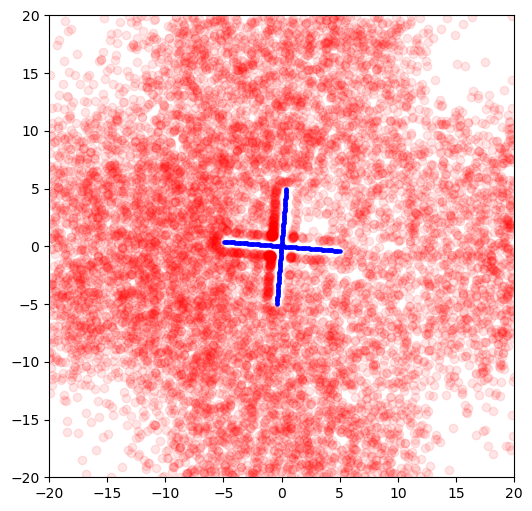

In [21]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))
centerX,centerY = af.config()
plt.scatter(centerX,centerY,s=5*af.Rb**2,color='blue')
plt.scatter(af.x,af.y,color='red',alpha=0.1)
plt.tight_layout
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.show()

data/wperturb/ensemble10: Dr=1, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=1.16439 +/- 0.024
data/wperturb/ensemble17: Dr=2, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=0.199707 +/- 0.0549
data/wperturb/ensemble16: Dr=3, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=-0.0647001 +/- 0.0193
data/wperturb/ensemble11: Dr=6, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=-0.354237 +/- 0.0343
data/wperturb/ensemble12: Dr=15, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=-0.342236 +/- 0.0214
data/wperturb/ensemble13: Dr=30, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=-0.278637 +/- 0.005
data/wperturb/ensemble14: Dr=90, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=-0.172863 +/- 0.00276
data/wperturb/ensemble15: Dr=150, loaded per omega=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3], small-omega slope=-0.11142 +/- 0.00236


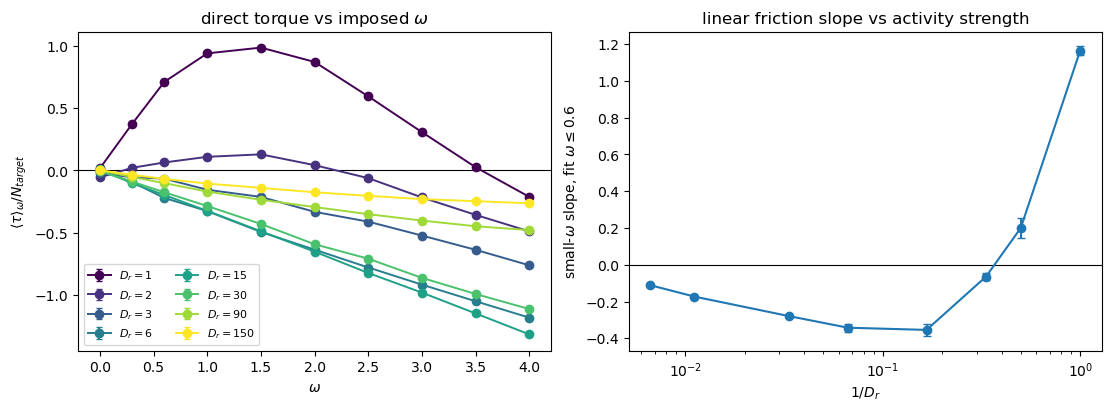

In [1]:
# 1. measure direct friction (fixed omega): <tau>_omega for different activity strengths Dr
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
%matplotlib inline

# Stationary fixed-omega batches where Dr was varied.
direct_dirs = [f'data/wperturb/ensemble{i}' for i in range(10, 18)]
omega_list = [0, 0.3, 0.6, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
domega = 0
small_omega_max = 0.6

# Keep the old convention in this notebook: plot per-target-particle torque.
DIRECT_TAU_SCALE = 10000
MAX_DIRECT_TAUBAR_ABS = 1e8
MAX_DIRECT_CORR_ABS = 1e12


def float_labels(x):
    labels = [str(x), f'{x:g}', f'{x:.1f}', f'{x:.2f}', f'{x:.3f}', f'{x:.6f}']
    if abs(x - round(x)) < 1e-12:
        labels.append(str(int(round(x))))
    out = []
    for label in labels:
        if label not in out:
            out.append(label)
    return out


def weighted_mean_and_sem(values, weights, scale=1.0):
    values = np.asarray(values, dtype=float) / scale
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]
    if len(values) == 0:
        return np.nan, np.nan
    mean = np.average(values, weights=weights)
    if len(values) < 2:
        return mean, 0.0
    neff = weights.sum() ** 2 / np.sum(weights ** 2)
    if neff <= 1:
        return mean, 0.0
    var = np.sum(weights * (values - mean) ** 2) / weights.sum()
    return mean, np.sqrt(var / neff)


def find_stationary_files(directory, omega, domega=0):
    files = []
    for omega_label in float_labels(omega):
        for domega_label in float_labels(domega):
            pattern = os.path.join(os.getcwd(), directory, f'{omega_label}-{domega_label}seed*.npz')
            files.extend(glob.glob(pattern))
    return sorted(set(files))


def load_direct_tau_record(path):
    with np.load(path) as state_load:
        if 'taubar' in state_load:
            tau = float(state_load['taubar'])
        elif 'tau_traj' in state_load:
            tau = float(np.average(state_load['tau_traj']))
        else:
            raise KeyError('no taubar or tau_traj in file')

        if 'N_ens_stationary' in state_load:
            weight = float(state_load['N_ens_stationary'])
        elif 'N_ens' in state_load:
            weight = float(state_load['N_ens'])
        else:
            weight = 1.0

        Dr_value = float(state_load['Dr']) if 'Dr' in state_load else np.nan

        corr_max = 0.0
        if 'corr' in state_load:
            corr = np.asarray(state_load['corr'], dtype=float)
            corr_max = float(np.nanmax(np.abs(corr)))
        elif 'C_stationary' in state_load:
            corr = np.asarray(state_load['C_stationary'], dtype=float)
            corr_max = float(np.nanmax(np.abs(corr)))

    if not np.isfinite(tau) or abs(tau) > MAX_DIRECT_TAUBAR_ABS:
        return None
    if not np.isfinite(corr_max) or corr_max > MAX_DIRECT_CORR_ABS:
        return None
    return tau, weight, Dr_value


def load_direct_curve(directory):
    tau_avg = np.full(len(omega_list), np.nan)
    tau_err = np.full(len(omega_list), np.nan)
    n_loaded = np.zeros(len(omega_list), dtype=int)
    Dr_seen = []

    for j, omega in enumerate(omega_list):
        values = []
        weights = []
        for file_path in find_stationary_files(directory, omega, domega=domega):
            try:
                record = load_direct_tau_record(file_path)
            except Exception as err:
                print(f'skip unreadable file: {os.path.basename(file_path)} ({err})')
                continue
            if record is None:
                print(f'skip overflow/corrupted file: {os.path.basename(file_path)}')
                continue
            tau, weight, Dr_value = record
            values.append(tau)
            weights.append(weight)
            if np.isfinite(Dr_value):
                Dr_seen.append(Dr_value)

        n_loaded[j] = len(values)
        tau_avg[j], tau_err[j] = weighted_mean_and_sem(values, weights, scale=DIRECT_TAU_SCALE)

    Dr_label = float(np.median(Dr_seen)) if len(Dr_seen) else np.nan
    return {
        'directory': directory,
        'Dr': Dr_label,
        'omega': np.asarray(omega_list, dtype=float),
        'tau_avg': tau_avg,
        'tau_err': tau_err,
        'n_loaded': n_loaded,
    }


def fit_small_omega_slope(result, omega_max=0.6):
    omega = result['omega']
    tau = result['tau_avg']
    err = result['tau_err']
    mask = np.isfinite(omega) & np.isfinite(tau) & (omega <= omega_max)
    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan

    x = omega[mask]
    y = tau[mask]
    sigma = err[mask]
    good_sigma = np.isfinite(sigma) & (sigma > 0)
    if np.sum(good_sigma) == len(sigma):
        coeff, cov = np.polyfit(x, y, 1, w=1.0 / sigma, cov=True)
        slope_err = float(np.sqrt(cov[0, 0])) if cov.shape == (2, 2) else np.nan
    else:
        coeff = np.polyfit(x, y, 1)
        if len(x) > 2:
            residual = y - np.polyval(coeff, x)
            s2 = np.sum(residual**2) / (len(x) - 2)
            sx2 = np.sum((x - np.mean(x))**2)
            slope_err = float(np.sqrt(s2 / sx2)) if sx2 > 0 else np.nan
        else:
            slope_err = np.nan
    return float(coeff[0]), float(coeff[1]), slope_err


direct_results = [load_direct_curve(directory) for directory in direct_dirs]
direct_results = [r for r in direct_results if np.isfinite(r['Dr'])]
direct_results = sorted(direct_results, key=lambda r: r['Dr'])

for result in direct_results:
    slope, intercept, slope_err = fit_small_omega_slope(result, omega_max=small_omega_max)
    result['small_omega_slope'] = slope
    result['small_omega_intercept'] = intercept
    result['small_omega_slope_err'] = slope_err
    print(
        f"{result['directory']}: Dr={result['Dr']:g}, "
        f"loaded per omega={result['n_loaded'].tolist()}, "
        f"small-omega slope={slope:.6g} +/- {slope_err:.3g}"
    )

fig, (ax_tau, ax_slope) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0, 1, max(len(direct_results), 1)))

for color, result in zip(colors, direct_results):
    label = fr'$D_r={result["Dr"]:g}$'
    ax_tau.errorbar(
        result['omega'],
        result['tau_avg'],
        yerr=result['tau_err'],
        marker='o',
        capsize=2,
        lw=1.4,
        color=color,
        label=label,
    )

slope_Dr = np.array([r['Dr'] for r in direct_results], dtype=float)
slope_values = np.array([r['small_omega_slope'] for r in direct_results], dtype=float)
slope_errors = np.array([r['small_omega_slope_err'] for r in direct_results], dtype=float)

ax_slope.errorbar(
    1/slope_Dr,
    slope_values,
    yerr=slope_errors,
    fmt='o-',
    capsize=3,
    color='tab:blue',
)

ax_tau.axhline(0, color='k', lw=0.8)
ax_tau.set_xlabel(r'$\omega$')
ax_tau.set_ylabel(r'$\langle \tau \rangle_\omega / N_{target}$')
ax_tau.set_title(r'direct torque vs imposed $\omega$')
ax_tau.legend(fontsize=8, ncols=2)

ax_slope.axhline(0, color='k', lw=0.8)
ax_slope.set_xlabel(r'$1/D_r$')
ax_slope.set_ylabel(fr'small-$\omega$ slope, fit $\omega \leq {small_omega_max:g}$')
ax_slope.set_title(r'linear friction slope vs activity strength')
ax_slope.set_xscale('log')
# ax_slope.set_xscale('log')

plt.show()

# Keep these names for any later cells that expect one selected direct-friction curve.
if len(direct_results):
    direc_data = direct_results[-1]['directory']
    tau_avg = direct_results[-1]['tau_avg']
    tau_err = direct_results[-1]['tau_err']
    n_loaded_direct = direct_results[-1]['n_loaded']


/tmp/ipykernel_3175277/1243316514.py:188: RuntimeWarning: invalid value encountered in divide
  (pol_mag, meas['polarization_x']/pol_mag, meas['polarization_y']/pol_mag, 'polarization', '|p|'),
/tmp/ipykernel_3175277/1243316514.py:189: RuntimeWarning: invalid value encountered in divide
  (flow_body_speed, flow_body_x/flow_body_speed, flow_body_y/flow_body_speed, 'deterministic flow on rotating grid', '|v_det+v_rot|'),


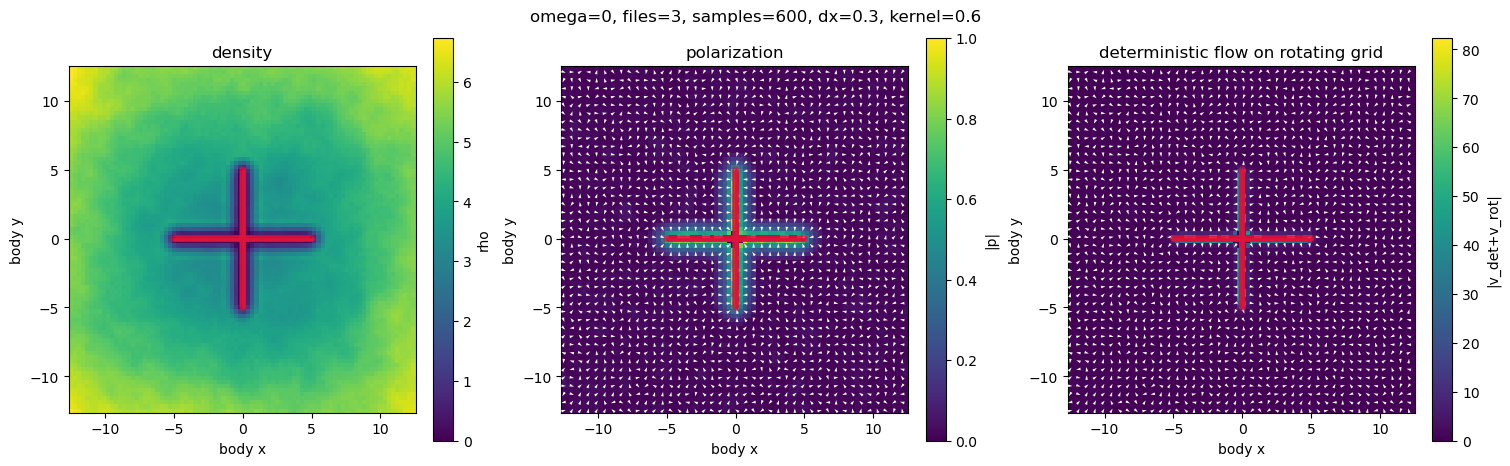

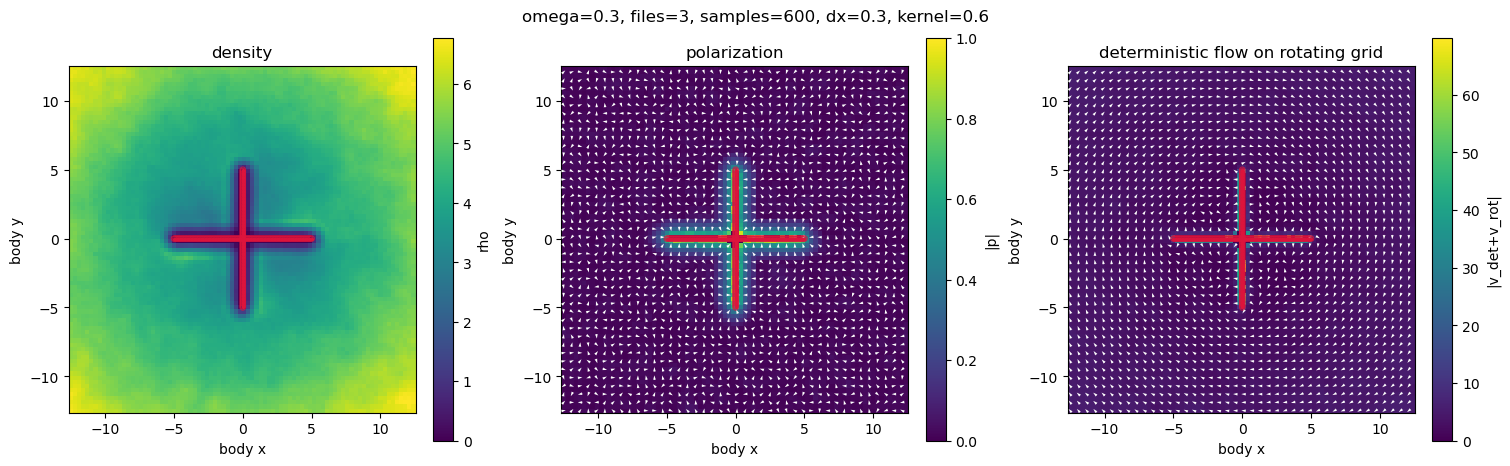

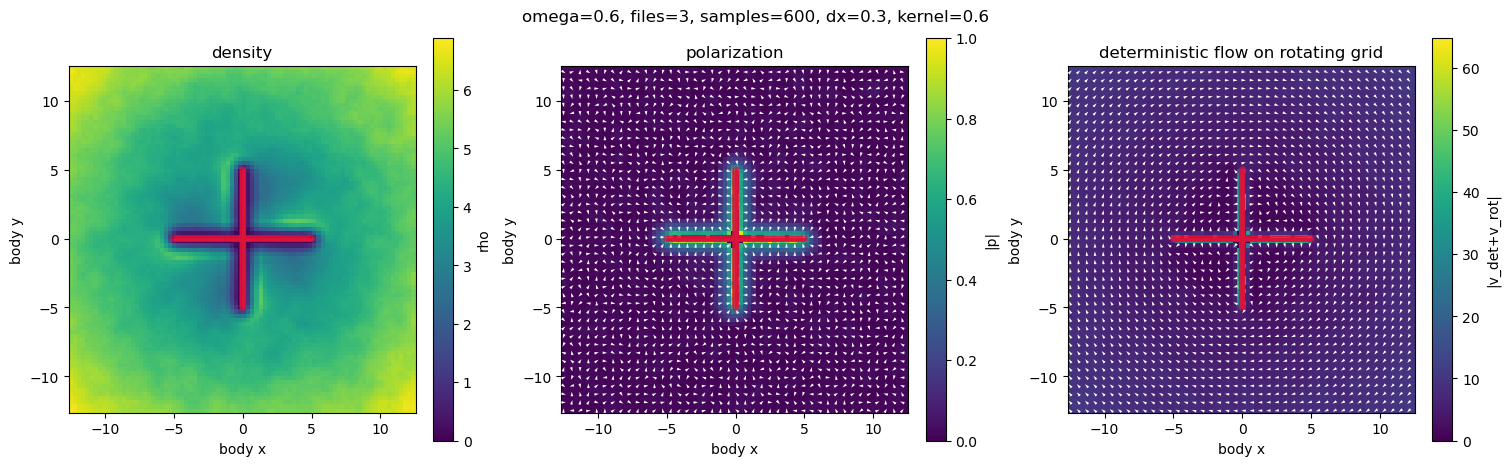

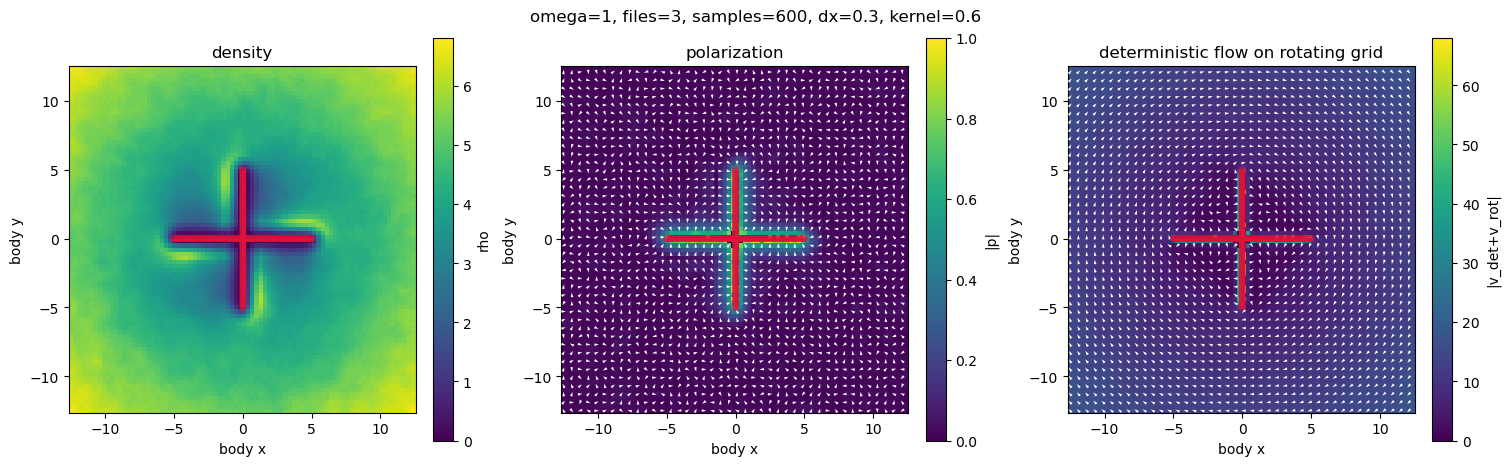

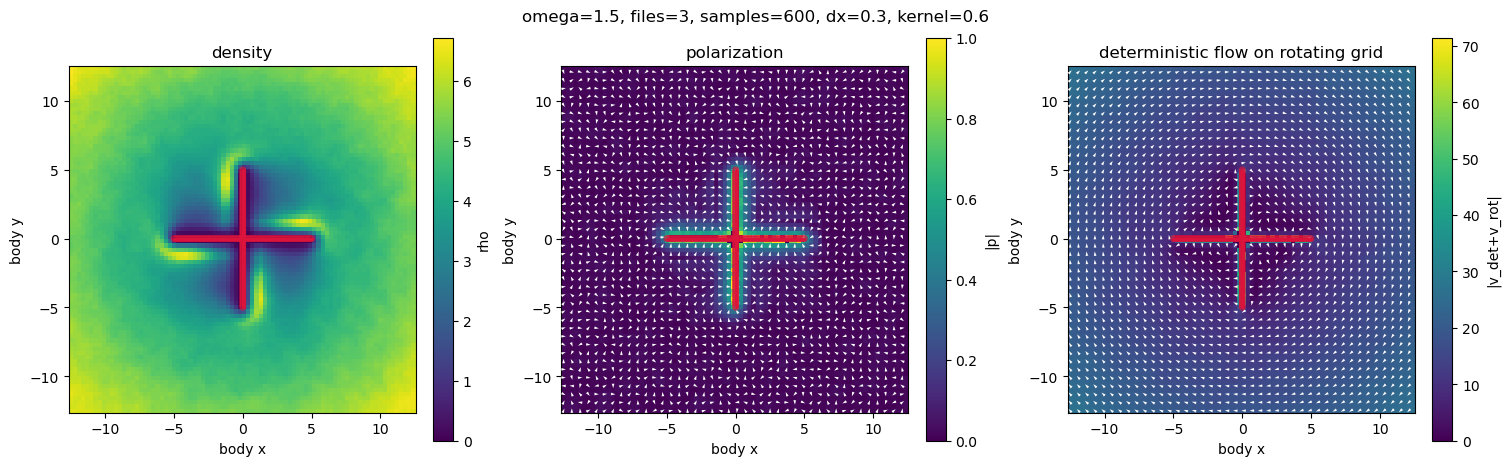

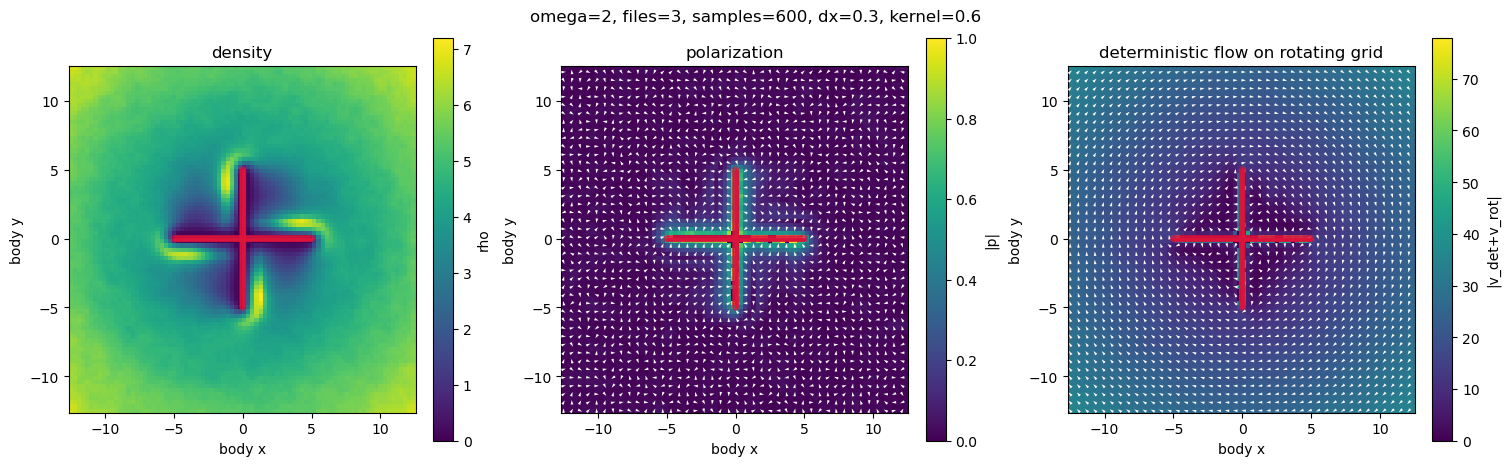

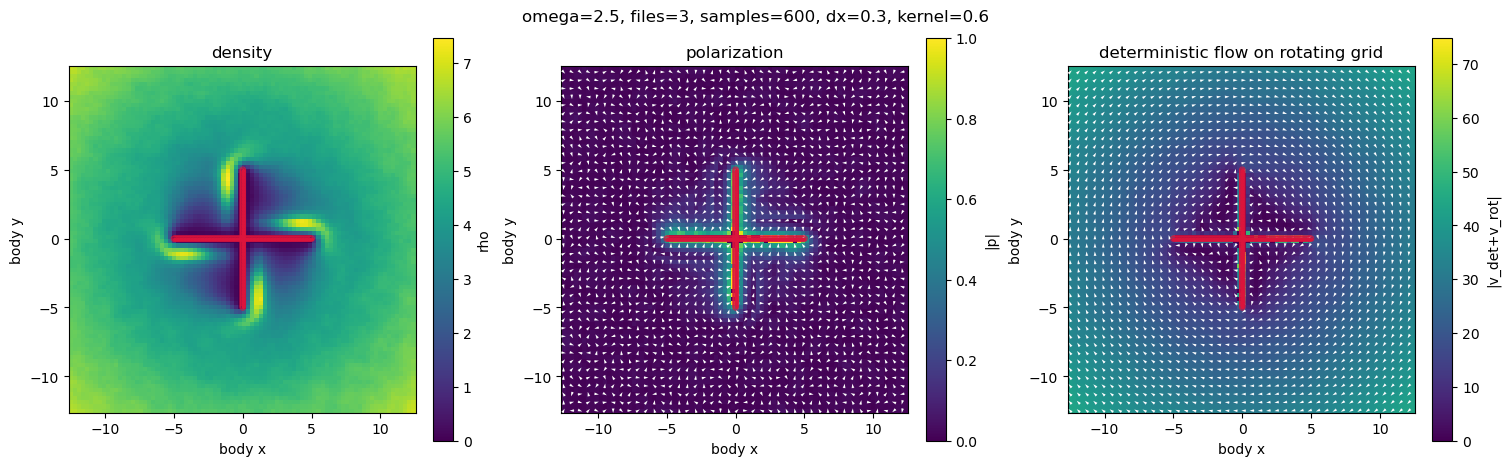

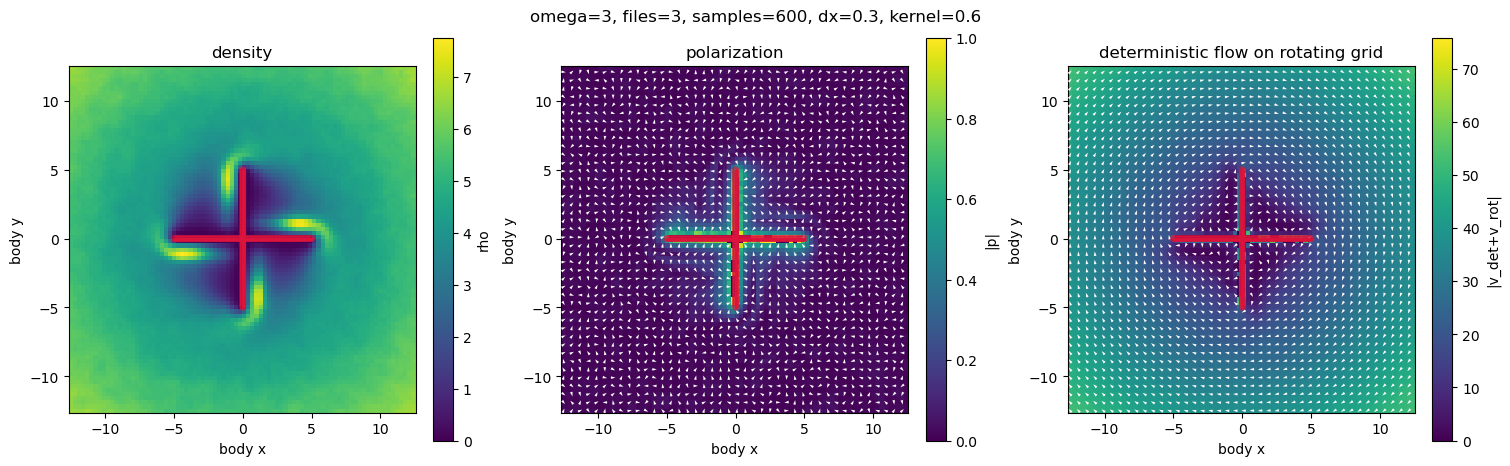

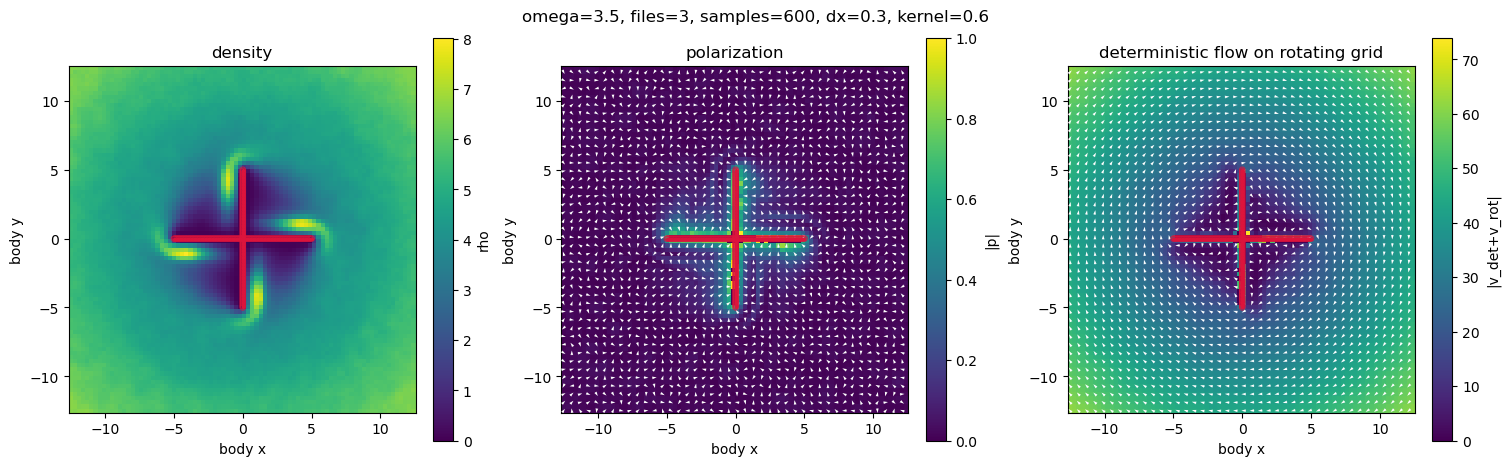

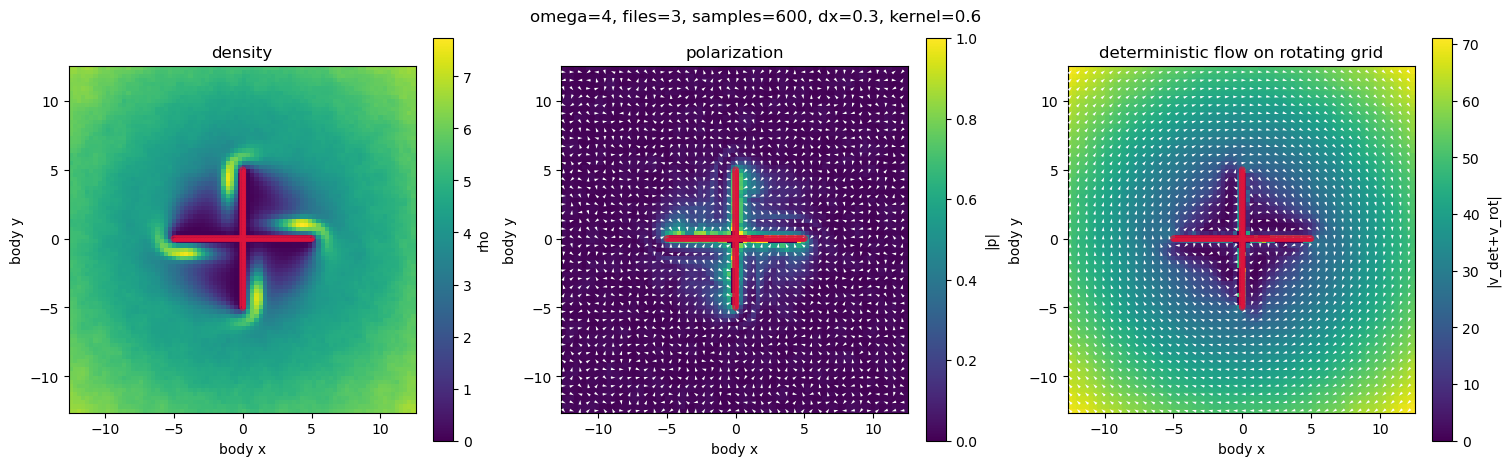

In [1]:
# 1b. visualize body-fixed local density, polarization, and flow around the gear
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle

# This cell expects stationary domega=0 files generated by run_wperturb_ens.py.
# It reuses the direct-friction directory above when available.
# direc_measure = 'data/wperturb/ensemble21'
direc_measure = 'data/wperturb/ensemble14'

omega_list = [0, 0.3, 0.6, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
omega_measure_list = omega_list
seed_measure = None  # None averages all measured seeds for each omega; set an int to inspect one seed.
plot_stride = 2


def float_labels(x):
    labels = [str(x), f'{x:g}', f'{x:.1f}', f'{x:.2f}', f'{x:.3f}', f'{x:.6f}']
    if abs(x - round(x)) < 1e-12:
        labels.append(str(int(round(x))))
    out = []
    for label in labels:
        if label not in out:
            out.append(label)
    return out


def find_local_measurement_files(directory, omega, seed=None):
    paths = []
    seed_labels = [seed] if seed is not None else ['*']
    for seed_label in seed_labels:
        for omega_label in float_labels(omega):
            pattern = os.path.join(os.getcwd(), directory, f'{omega_label}-0seed{seed_label}.npz')
            paths.extend(sorted(glob.glob(pattern)))

    if not paths:
        pattern = os.path.join(os.getcwd(), directory, '*-0seed*.npz')
        paths = sorted(glob.glob(pattern))

    found = []
    seen = set()
    for candidate in paths:
        if candidate in seen:
            continue
        seen.add(candidate)
        with np.load(candidate) as data:
            if 'measure_density' not in data:
                continue
            if abs(float(data['omega']) - omega) < 1e-10:
                found.append(candidate)
    return found


def gear_body_points(R, N_body=20):
    thetas = np.linspace(-np.pi / 6, np.pi / 6, N_body)
    x1 = -R * np.cos(thetas) + 2 / np.sqrt(3) * R
    y1 = -R * np.sin(thetas)
    x2 = -R * np.cos(thetas + 2 * np.pi / 3) - 1 / np.sqrt(3) * R
    y2 = -R * np.sin(thetas + 2 * np.pi / 3) + R
    x3 = -R * np.cos(thetas - 2 * np.pi / 3) - 1 / np.sqrt(3) * R
    y3 = -R * np.sin(thetas - 2 * np.pi / 3) - R
    return np.concatenate([x1, x2, x3]), np.concatenate([y1, y2, y3])


def draw_gear_body(ax, R, Rb=1.0, N_body=20, body_x=None, body_y=None):
    if body_x is None or body_y is None:
        gx, gy = gear_body_points(R, N_body=N_body)
    else:
        gx = np.asarray(body_x, dtype=float).ravel()
        gy = np.asarray(body_y, dtype=float).ravel()
    circles = [Circle((x, y), Rb) for x, y in zip(gx, gy)]
    body = PatchCollection(
        circles,
        facecolor='none',
        edgecolor='crimson',
        linewidth=0.8,
        alpha=0.75,
        zorder=4,
    )
    ax.add_collection(body)
    ax.plot(gx, gy, '.', color='crimson', ms=2.5, zorder=5)


def body_rotation_velocity(X, Y, omega):
    # Velocity contribution from describing lab motion on a rotating body-fixed grid:
    # v_body = R(-theta) v_lab - omega z cross r_body.
    return omega * Y, -omega * X


def rotating_grid_flow(X, Y, flow_x, flow_y, omega, flow_frame):
    # New files save measure_flow in the rotating body frame.
    # Older files saved deterministic lab velocity rotated into body axes, so add frame velocity.
    if str(flow_frame) == 'rotating_body_fixed':
        return flow_x, flow_y
    rot_x, rot_y = body_rotation_velocity(X, Y, omega)
    return flow_x + rot_x, flow_y + rot_y


def load_averaged_local_measurement(paths):
    if len(paths) == 0:
        return None

    accum = None
    for path in paths:
        with np.load(path) as data:
            n_samples = int(data['measure_n_samples'])
            count = np.asarray(data['measure_count'], dtype=float)
            density = np.asarray(data['measure_density'], dtype=float)
            pol_x = np.asarray(data['measure_polarization_x'], dtype=float)
            pol_y = np.asarray(data['measure_polarization_y'], dtype=float)
            flow_x = np.asarray(data['measure_flow_x'], dtype=float)
            flow_y = np.asarray(data['measure_flow_y'], dtype=float)

            if accum is None:
                accum = {
                    'X': np.asarray(data['measure_grid_x'], dtype=float),
                    'Y': np.asarray(data['measure_grid_y'], dtype=float),
                    'R': float(data['R']),
                    'Rb': float(data['Rb']) if 'Rb' in data else 1.0,
                    'lamb': float(data['lamb']) if 'lamb' in data else float(data['u']),
                    'mu': float(data['mu']) if 'mu' in data else 1.0,
                    'body_x': np.asarray(data['measure_body_x'], dtype=float) if 'measure_body_x' in data else None,
                    'body_y': np.asarray(data['measure_body_y'], dtype=float) if 'measure_body_y' in data else None,
                    'body_marker_radius': float(data['measure_body_marker_radius']) if 'measure_body_marker_radius' in data else (float(data['Rb']) if 'Rb' in data else 1.0),
                    'omega': float(data['omega']),
                    'flow_frame': str(data['measure_flow_frame']) if 'measure_flow_frame' in data else 'body_fixed_no_rotation',
                    'grid_spacing': float(data['measure_grid_spacing']),
                    'kernel_radius': float(data['measure_kernel_radius']),
                    'n_samples': 0,
                    'density_sample_sum': np.zeros_like(density),
                    'count_sum': np.zeros_like(count),
                    'pol_x_count_sum': np.zeros_like(pol_x),
                    'pol_y_count_sum': np.zeros_like(pol_y),
                    'flow_x_count_sum': np.zeros_like(flow_x),
                    'flow_y_count_sum': np.zeros_like(flow_y),
                }

            total_count = count * n_samples
            accum['n_samples'] += n_samples
            accum['density_sample_sum'] += density * n_samples
            accum['count_sum'] += total_count
            accum['pol_x_count_sum'] += pol_x * total_count
            accum['pol_y_count_sum'] += pol_y * total_count
            accum['flow_x_count_sum'] += flow_x * total_count
            accum['flow_y_count_sum'] += flow_y * total_count

    count_sum = accum['count_sum']
    n_samples = max(accum['n_samples'], 1)
    with np.errstate(divide='ignore', invalid='ignore'):
        accum['density'] = accum['density_sample_sum'] / n_samples
        accum['polarization_x'] = np.divide(
            accum['pol_x_count_sum'], count_sum, out=np.zeros_like(count_sum), where=count_sum > 0
        )
        accum['polarization_y'] = np.divide(
            accum['pol_y_count_sum'], count_sum, out=np.zeros_like(count_sum), where=count_sum > 0
        )
        accum['flow_x'] = np.divide(
            accum['flow_x_count_sum'], count_sum, out=np.zeros_like(count_sum), where=count_sum > 0
        )
        accum['flow_y'] = np.divide(
            accum['flow_y_count_sum'], count_sum, out=np.zeros_like(count_sum), where=count_sum > 0
        )
    return accum


def plot_local_measurements_for_omega(omega, stride=2, seed=None):
    paths = find_local_measurement_files(direc_measure, omega, seed=seed)
    meas = load_averaged_local_measurement(paths)
    if meas is None:
        print(f'No local-field file found in {direc_measure} for omega={omega:g}.')
        return None

    X = meas['X']
    Y = meas['Y']
    flow_body_x, flow_body_y = rotating_grid_flow(
        X, Y, meas['flow_x'], meas['flow_y'], meas['omega'], meas['flow_frame']
    )
    pol_mag = np.hypot(meas['polarization_x'], meas['polarization_y'])
    flow_body_speed = np.hypot(flow_body_x, flow_body_y)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
    panels = [
        (meas['density'], None, None, 'density', 'rho'),
        (pol_mag, meas['polarization_x']/pol_mag, meas['polarization_y']/pol_mag, 'polarization', '|p|'),
        (flow_body_speed, flow_body_x/flow_body_speed, flow_body_y/flow_body_speed, 'deterministic flow on rotating grid', '|v_det+v_rot|'),
    ]

    for ax, (field, vx, vy, title, cbar_label) in zip(axes, panels):
        im = ax.pcolormesh(X, Y, field, shading='auto', cmap='viridis')
        if vx is not None:
            ax.quiver(
                X[::stride, ::stride],
                Y[::stride, ::stride],
                vx[::stride, ::stride],
                vy[::stride, ::stride],
                color='white',
                pivot='mid',
                scale=None,
                width=0.004,
                zorder=3,
            )
        draw_gear_body(
            ax,
            meas['R'],
            Rb=meas['body_marker_radius']/5,
            body_x=meas['body_x'],
            body_y=meas['body_y'],
        )
        ax.set_aspect('equal', 'box')
        ax.set_xlabel('body x')
        ax.set_ylabel('body y')
        ax.set_title(title)
        fig.colorbar(im, ax=ax, label=cbar_label)

    fig.suptitle(
        f'omega={omega:g}, files={len(paths)}, samples={meas["n_samples"]}, '
        f'dx={meas["grid_spacing"]:g}, kernel={meas["kernel_radius"]:g}'
    )
    plt.show()
    return meas


def plot_flow_for_omega_list(omega_values, stride=2, seed=None, ncols=3):
    flow_records = []
    for omega in omega_values:
        paths = find_local_measurement_files(direc_measure, omega, seed=seed)
        meas = load_averaged_local_measurement(paths)
        if meas is None:
            print(f'skip omega={omega:g}: no local-field file')
            continue
        flow_body_x, flow_body_y = rotating_grid_flow(
            meas['X'], meas['Y'], meas['flow_x'], meas['flow_y'], meas['omega'], meas['flow_frame']
        )
        flow_records.append((omega, paths, meas, flow_body_x, flow_body_y, np.hypot(flow_body_x, flow_body_y)))

    if len(flow_records) == 0:
        return []

    vmax = max(np.nanmax(record[-1]) for record in flow_records)
    ncols = min(ncols, len(flow_records))
    nrows = math.ceil(len(flow_records) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.6 * nrows), squeeze=False, constrained_layout=True)

    last_im = None
    for ax in axes.ravel():
        ax.set_visible(False)

    for ax, (omega, paths, meas, vx, vy, speed) in zip(axes.ravel(), flow_records):
        ax.set_visible(True)
        X = meas['X']
        Y = meas['Y']
        last_im = ax.pcolormesh(X, Y, speed, shading='auto', cmap='magma', vmin=0, vmax=vmax)
        ax.quiver(
            X[::stride, ::stride],
            Y[::stride, ::stride],
            vx[::stride, ::stride],
            vy[::stride, ::stride],
            color='white',
            pivot='mid',
            scale=None,
            width=0.004,
            zorder=3,
        )
        draw_gear_body(
            ax,
            meas['R'],
            Rb=meas['body_marker_radius']/5,
            body_x=meas['body_x'],
            body_y=meas['body_y'],
        )
        ax.set_aspect('equal', 'box')
        ax.set_xlabel('body x')
        ax.set_ylabel('body y')
        ax.set_title(f'omega={omega:g}, files={len(paths)}')

    fig.colorbar(last_im, ax=axes.ravel().tolist(), label='|v_det+v_rot|')
    fig.suptitle('deterministic rotating-grid flow for all measured omega')
    plt.show()
    return flow_records


# Detailed density/polarization/flow plot for one omega.
for omega_measure in omega_measure_list:
    plot_local_measurements_for_omega(omega_measure, stride=plot_stride, seed=seed_measure)

# Flow-only comparison across the full omega list.
# flow_records = plot_flow_for_omega_list(omega_measure_list, stride=plot_stride, seed=seed_measure, ncols=3)


$$
D_R= \int _0 ^\infty ds \langle \tau e^{\mathcal{L}_B s } \tau \rangle_B = \int _0 ^\infty ds \langle \tau(s) \tau(0) \rangle_B$$

$$\gamma_R = \int_0 ^\infty ds\langle \tau e^{\mathcal{L}_B s} \partial_\Theta \ln \pi_B \rangle _B =\int_0 ^\infty ds \langle \tau (s) \partial_\Theta \ln \pi _B (0) \rangle _B\\
=\int_0^\infty ds\lim_{\Delta\Theta\to 0}{1\over \Delta\Theta}[\left<\tau(s)\right>_{\Theta+\Delta\Theta\to\Theta}-\left<\tau(s)\right>_{\Theta}]

$$

/tmp/ipykernel_1268154/3848275355.py:23: RuntimeWarning: invalid value encountered in divide
  ax1.plot(time[:800],-0.001*np.cumsum(traj[:800])/dtheta,label=str(dtheta))
/tmp/ipykernel_1268154/3848275355.py:24: RuntimeWarning: invalid value encountered in divide
  ax2.plot(time[:800],-traj[:800]/dtheta,label=str(dtheta))


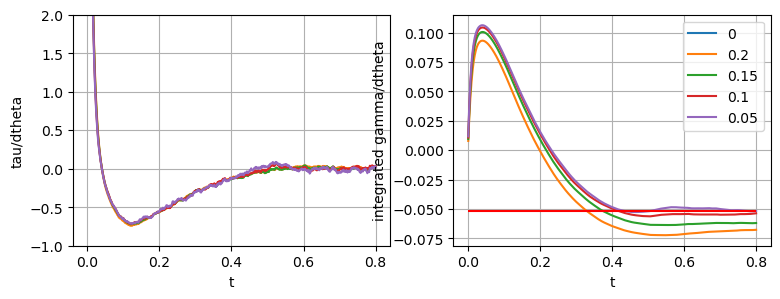

In [5]:
# 2. small omega friction gamma: measure dtheta perturbation
import numpy as np
import os
import matplotlib.pyplot as plt
dtheta_list = [0, 0.2,0.15,0.1,0.05]
direc_save= 'data/perturb/7/'
time = (np.arange(3000)+1)/1000
fig, (ax2,ax1)= plt.subplots(1,2,figsize=(9,3))
for dtheta in dtheta_list:
    traj = np.zeros(3000)
    count=0
    for i in range(20):
        try:
            state = os.getcwd()+'/'+direc_save+str(dtheta)+'seed'+str(i)+'.npz'
            state_load = np.load(state)
            stateref = os.getcwd()+'/'+direc_save+str(0)+'seed'+str(i)+'.npz'
            stateref_load = np.load(stateref)
            traj += state_load['tau_traj']-stateref_load['tau_traj']
            count += 1
        except:
            pass
    traj /= count
    ax1.plot(time[:800],-0.001*np.cumsum(traj[:800])/dtheta,label=str(dtheta))
    ax2.plot(time[:800],-traj[:800]/dtheta,label=str(dtheta))
ax1.legend()
ax1.grid()
ax1.set_xlabel('t')
ax1.hlines(-slope,0,0.8,colors='red')
# plt.ylim(-1,1)
ax1.set_ylabel('integrated gamma/dtheta')
# ax2.legend()
ax2.grid()
ax2.set_xlabel('t')
ax2.set_ylabel('tau/dtheta')
ax2.set_ylim(-1,2)
plt.show()

$$
B(\Omega) = N\int_0 ^\infty ds\langle \tau(r(s));\tau(r(0))\rangle_\Omega\\
$$

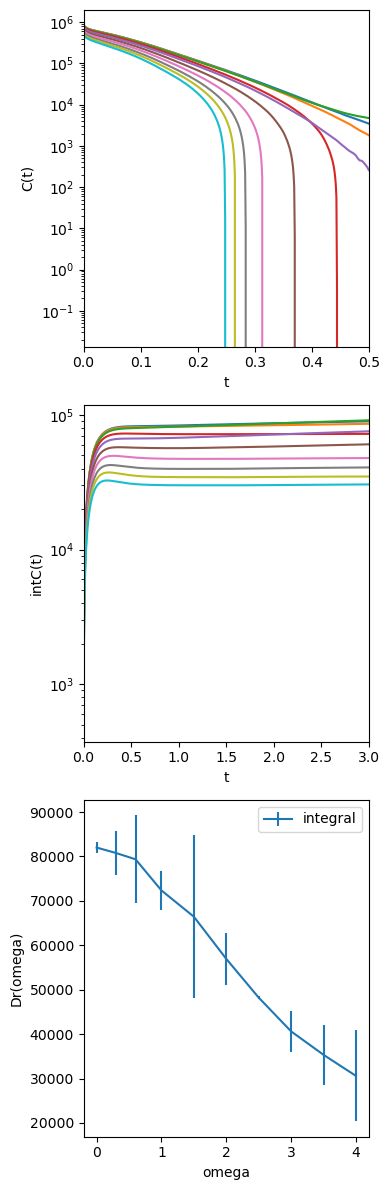

In [2]:
# 3. diffusion term, measure autocorrelation function at fixed omega
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# direc_data = 'data/wperturb/particle_self_split_full'

direc_data = 'data/wperturb/ensemble4'
# direc_data = 'data/wperturb/common_seed_pilot'

omega_list = [0, 0.3, 0.6, 1, 1.5, 2, 2.5, 3, 3.5, 4]
domega = 0
dt = 0.001
len_corr = 3000
nseed_stationary = 5

# def exp_fit(t, a, b):
#     return a * np.exp(-b * t)




Dr_int = np.full(len(omega_list), np.nan)
Dr_err = np.full(len(omega_list), np.nan)
tau_avg = np.full(len(omega_list), np.nan)

def weighted_sem(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]
    if len(values) < 2:
        return 0.0
    mean = np.average(values, weights=weights)
    neff = weights.sum() ** 2 / np.sum(weights ** 2)
    if neff <= 1:
        return 0.0
    var = np.sum(weights * (values - mean) ** 2) / weights.sum()
    return np.sqrt(var / neff)

MAX_STATIONARY_TAUBAR_ABS = 1e8
MAX_STATIONARY_CORR_ABS = 1e12

def stationary_record_is_valid(taubar, corr):
    if not np.isfinite(taubar):
        return False
    if not np.all(np.isfinite(corr)):
        return False
    if abs(taubar) > MAX_STATIONARY_TAUBAR_ABS:
        return False
    if np.max(np.abs(corr)) > MAX_STATIONARY_CORR_ABS:
        return False
    return True

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 12))

for j, omega in enumerate(omega_list):

    records = []

    for i in range(nseed_stationary):
        state = os.path.join(
            os.getcwd(),
            direc_data,
            f'{omega}-{domega}seed{i}.npz'
        )

        if not os.path.exists(state):
            continue

        with np.load(state) as state_load:
            m = float(state_load['taubar'])
            corr = np.array(state_load['corr'], dtype=float, copy=True)
            if 'N_ens_stationary' in state_load:
                weight = float(state_load['N_ens_stationary'])
            elif 'N_ens' in state_load:
                weight = float(state_load['N_ens'])
            else:
                weight = 1.0

        if not stationary_record_is_valid(m, corr):
            print(
                f'skip overflow/corrupted stationary file: {os.path.basename(state)} '
                f'taubar={m:.3g}, max|corr|={np.nanmax(np.abs(corr)):.3g}'
            )
            continue

        records.append((m, corr, weight))

    if len(records) == 0:
        print(f'omega={omega}: no files found')
        continue

    weights = np.array([r[2] for r in records], dtype=float)
    mu = np.average([r[0] for r in records], weights=weights)
    tau_avg[j] = mu
    corr_mean = np.average(np.stack([r[1] for r in records]), axis=0, weights=weights)
    autocorr = corr_mean - mu**2
    time = np.arange(len(autocorr)) * dt

    ax1.plot(time, autocorr)
    ax2.plot(time, np.cumsum(autocorr)*dt)

    # 적분은 기존 npz 생성 코드와 일관되게 trapz 추천
    Dr_int[j] = np.trapz(autocorr[time<0.5], dx=dt)
    seed_Dr = np.array([np.trapz(r[1][time<0.5] - mu**2, dx=dt) for r in records])
    Dr_err[j] = weighted_sem(seed_Dr, weights)

    
ax3.errorbar(omega_list, Dr_int,yerr=Dr_err, label='integral')

ax1.set_xlabel('t')
ax1.set_ylabel('C(t)')
ax1.set_yscale('log')
ax1.set_xlim(0, 0.5)

ax2.set_xlabel('t')
ax2.set_ylabel('intC(t)')
ax2.set_yscale('log')
ax2.set_xlim(0, 3)

ax3.set_xlabel('omega')
ax3.set_ylabel('Dr(omega)')
ax3.legend()

plt.tight_layout()
plt.show()

$$
G(\Omega) = N\int_0^\infty ds\langle \tau(r(s));\tau(r(0))\partial_\Omega \ln \pi_\Omega(r(0))\rangle_\Omega
\\=N\int_0^\infty ds\lim_{\Delta\Omega\to 0}{1\over \Delta\Omega}[\left<\delta\tau(s)\tau(0)\right>_{\Omega+1/2\Delta\Omega\to\Omega}-\left<\delta\tau(s)\tau(0)\right>_{\Omega-1/2\Delta\Omega\to\Omega}]
$$

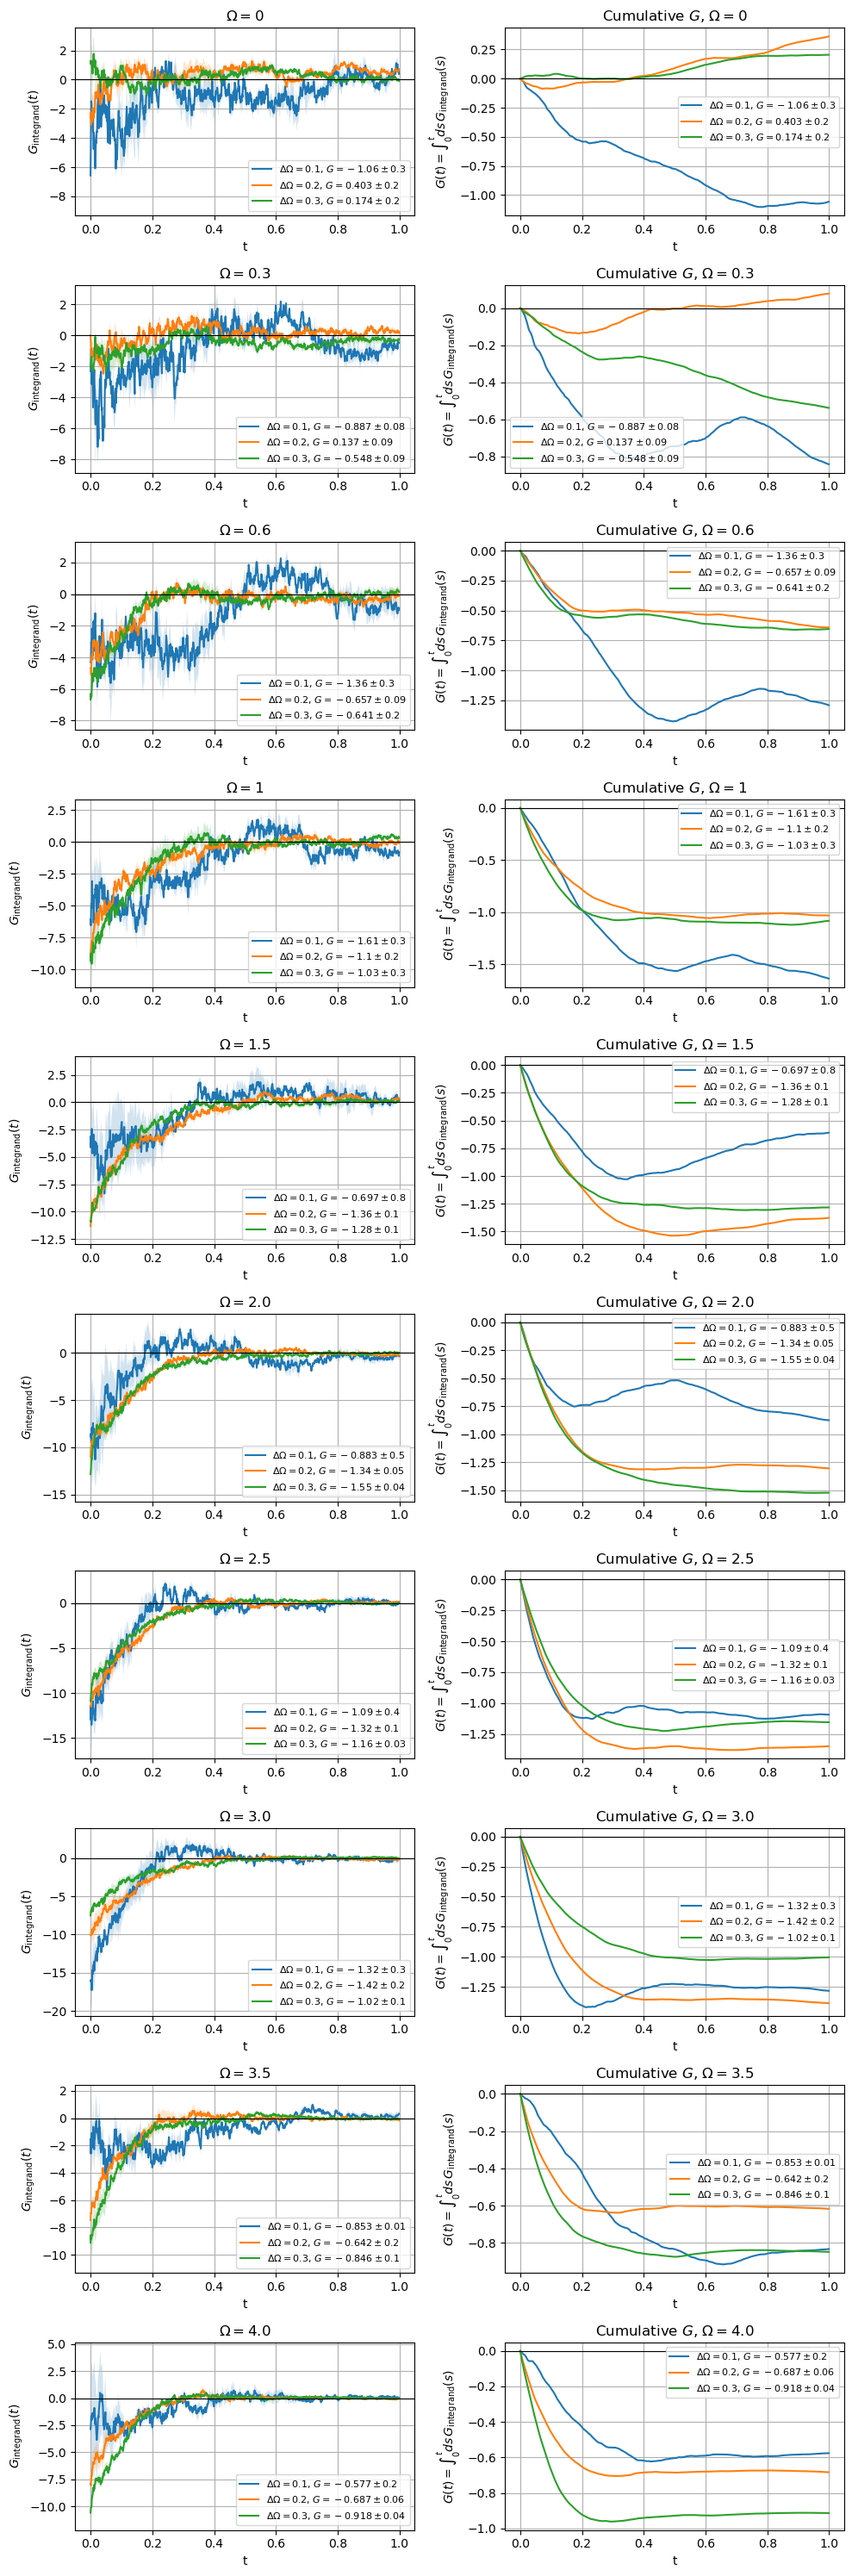

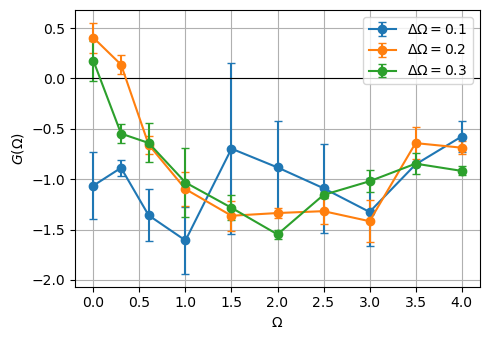

In [5]:
# 4. higher order drift G -> omega quench correlation
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# ===================== settings =====================
# direc_save = 'data/wperturb/particle_self_split_full/'   # 필요하면 수정
# direc_save = 'data/wperturb/ensemble2' # good result
direc_save = 'data/wperturb/ensemble4' # increased body number

omega_list = [0,0.3,0.6,1,1.5,2.0,2.5,3.0,3.5,4.0]
domega_list = [ 0.1, 0.2, 0.3]   # domega > 0 only
nseed = 60
plot_tmax = 1.0       # plot up to this time
plateau_frac = 0.2    # last 20% for plateau estimate

# ===================== helper =====================
def float_labels(x):
    labels = [str(x), f"{x:g}", f"{x:.1f}", f"{x:.2f}", f"{x:.3f}", f"{x:.6f}"]
    if abs(x - round(x)) < 1e-12:
        labels += [str(int(round(x)))]
    out = []
    for s in labels:
        if s not in out:
            out.append(s)
    return out

def find_file(omega, domega, seed):
    # Expected format: {omega}-{domega}seed{seed}.npz
    for olab in float_labels(omega):
        for dlab in float_labels(domega):
            path = os.path.join(os.getcwd(), direc_save, f"{olab}-{dlab}seed{seed}.npz")
            if os.path.exists(path):
                return path

    # fallback: glob and parse
    pattern = os.path.join(os.getcwd(), direc_save, f"*-*seed{seed}.npz")
    for path in glob.glob(pattern):
        base = os.path.basename(path).replace(".npz", "")
        try:
            left, rest = base.split("-", 1)
            mid, s = rest.split("seed", 1)
            if int(s) == seed and abs(float(left) - omega) < 1e-10 and abs(float(mid) - domega) < 1e-10:
                return path
        except Exception:
            pass
    return None

def cumtrapz_simple(y, dt):
    out = np.zeros_like(y, dtype=float)
    if len(y) > 1:
        out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * dt)
    return out

def weighted_axis_sem(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]
    if len(weights) < 2:
        return np.zeros(values.shape[1:], dtype=float)
    mean = np.average(values, axis=0, weights=weights)
    neff = weights.sum() ** 2 / np.sum(weights ** 2)
    if neff <= 1:
        return np.zeros(values.shape[1:], dtype=float)
    var = np.average((values - mean) ** 2, axis=0, weights=weights)
    return np.sqrt(var / neff)

# ===================== main analysis =====================
G_summary = {}

fig, axes = plt.subplots(len(omega_list), 2, figsize=(10, 3 * len(omega_list)), squeeze=False)

for row, omega in enumerate(omega_list):
    ax_int, ax_cum = axes[row]
    G_summary[omega] = {}
    taubar_omega = tau_avg[row]

    for domega in domega_list:
        if domega == 0:
            continue

        G_integrands = []
        G_values = []
        tau_plus = []
        tau_minus =[]
        # corr_plus = []
        # corr_minus = []
        fs = []
        Bs = []
        used_seeds = []
        G_weights = []
        dt = None

        for seed in range(nseed):
            path = find_file(omega, domega, seed)
            if path is None:
                continue

            data = np.load(path)

            # This file format already stores the central-difference G integrand.
            
            domega_file = float(data['domega']) if 'domega' in data else domega
            
            # Reconstruct quench correlations centered by the final fixed-omega mean.
            tau_plus_seed = data['tau_plus']
            tau_minus_seed = data['tau_minus']
            tau_plus.append(tau_plus_seed)
            tau_minus.append(tau_minus_seed)
            # corr_plus.append(data['corr_plus'])
            # corr_minus.append(data['corr_minus'])
            dt = float(data['dt'])
            if 'N_ens_quench' in data:
                weight = float(data['N_ens_quench'])
            elif 'N_ens' in data:
                weight = float(data['N_ens'])
            else:
                weight = 1.0

            
            # C_plus = data['corr_plus'] - taubar_omega * tau_plus_seed[0]
            # C_minus = data['corr_minus'] - taubar_omega * tau_minus_seed[0]
            C_plus = data['corr_plus'] - tau_plus_seed * tau_plus_seed[0]
            C_minus = data['corr_minus'] - tau_minus_seed * tau_minus_seed[0]
            
            gint = (C_plus - C_minus) / (2 * domega_file)
            

            G_integrands.append(gint)
            G_weights.append(weight)
            
            used_seeds.append(seed)

        if len(G_integrands) == 0:
            print(f"[skip] Omega={omega}, dOmega={domega}: no files")
            continue

        # Trim to common length
        min_len = min(len(g) for g in G_integrands)
        G_integrands = np.array([g[:min_len] for g in G_integrands])
        G_weights = np.array(G_weights, dtype=float)

        # Ensemble over outer job seeds, weighted by the number of quench replicas in each file.
        G_int_mean = np.average(G_integrands, axis=0, weights=G_weights)
        G_int_sem = weighted_axis_sem(G_integrands, G_weights)

        time = np.arange(min_len) * dt
        G_cum = cumtrapz_simple(G_int_mean, dt)

        # Error bar for final/plateau from seed-wise cumulative integrals
        G_cums_seed = np.array([cumtrapz_simple(g, dt) for g in G_integrands])
        n_plateau = max(1, int(plateau_frac * min_len))

        G_plateau_seed = np.mean(G_cums_seed[:, -n_plateau:], axis=1)
        G_plateau = float(np.average(G_plateau_seed, weights=G_weights))
        G_plateau_sem = float(weighted_axis_sem(G_plateau_seed[:, None], G_weights)[0])

        G_file_mean = float(np.mean(G_values)) if len(G_values) else np.nan
        G_file_sem = float(np.std(G_values, ddof=1) / np.sqrt(len(G_values))) if len(G_values) > 1 else 0.0

        G_summary[omega][domega] = {
            'time': time,
            'G_integrand_mean': G_int_mean,
            'G_integrand_sem': G_int_sem,
            'G_cumulative': G_cum,
            'G_plateau': G_plateau,
            'G_plateau_sem': G_plateau_sem,
            'G_file_mean': G_file_mean,
            'G_file_sem': G_file_sem,
            'used_seeds': used_seeds,
            'used_weights': G_weights,
            'total_N_ens_quench': float(np.sum(G_weights)),
            'taubar_mean': taubar_omega,
            'f_mean': np.mean(fs) if len(fs) else np.nan,
            'B_mean': np.mean(Bs) if len(Bs) else np.nan,
        }

        imax = min(len(time), int(plot_tmax / dt))

        label = rf"$\Delta\Omega={domega}$, $G={G_plateau:.3g}\pm{G_plateau_sem:.1g}$"

        ax_int.plot(time[:imax], G_int_mean[:imax], label=label)
        ax_int.fill_between(
            time[:imax],
            G_int_mean[:imax] - G_int_sem[:imax],
            G_int_mean[:imax] + G_int_sem[:imax],
            alpha=0.2,
        )

        ax_cum.plot(time[:imax], G_cum[:imax], label=label)

        

    ax_int.axhline(0, color='k', lw=0.8)
    ax_int.grid()
    ax_int.legend(fontsize=8)
    ax_int.set_xlabel("t")
    ax_int.set_ylabel(r"$G_{\rm integrand}(t)$")
    ax_int.set_title(rf"$\Omega={omega}$")

    ax_cum.axhline(0, color='k', lw=0.8)
    ax_cum.grid()
    ax_cum.legend(fontsize=8)
    ax_cum.set_xlabel("t")
    ax_cum.set_ylabel(r"$G(t)=\int_0^t ds\,G_{\rm integrand}(s)$")
    ax_cum.set_title(rf"Cumulative $G$, $\Omega={omega}$")

plt.tight_layout()
plt.show()

# ===================== compact G(Omega) plot =====================
plt.figure(figsize=(5, 3.5))

for domega in domega_list:
    xs, ys, es = [], [], []
    for omega in omega_list:
        if omega in G_summary and domega in G_summary[omega]:
            xs.append(omega)
            ys.append(G_summary[omega][domega]['G_plateau'])
            es.append(G_summary[omega][domega]['G_plateau_sem'])
    if len(xs):
        plt.errorbar(xs, ys, yerr=es, marker='o', capsize=3, label=rf"$\Delta\Omega={domega}$")

plt.axhline(0, color='k', lw=0.8)
plt.xlabel(r"$\Omega$")
plt.ylabel(r"$G(\Omega)$")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

PDF scaling: free N=5000, landscape N=10000, N_scale=0.5
tau and B are scaled by N_scale; per-particle G is scaled by N_free.
tau powers/coeff: [1, 3, 5] [229.05626388 -43.32223111   1.2778082 ]
B powers/coeff/floor: [0, 2, 4] [40324.03959669 -3223.34566124   106.01324519] 765.0961831092368
G powers/coeff: [1, 3, 5] [-5986.25103255   684.82918916   -23.62855228] G from G_summary plateaus scaled by N_free=5000


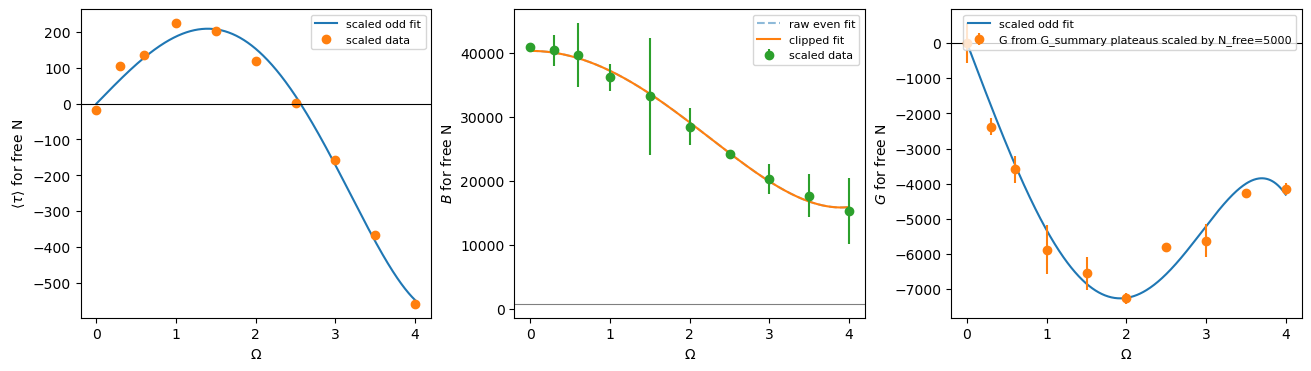

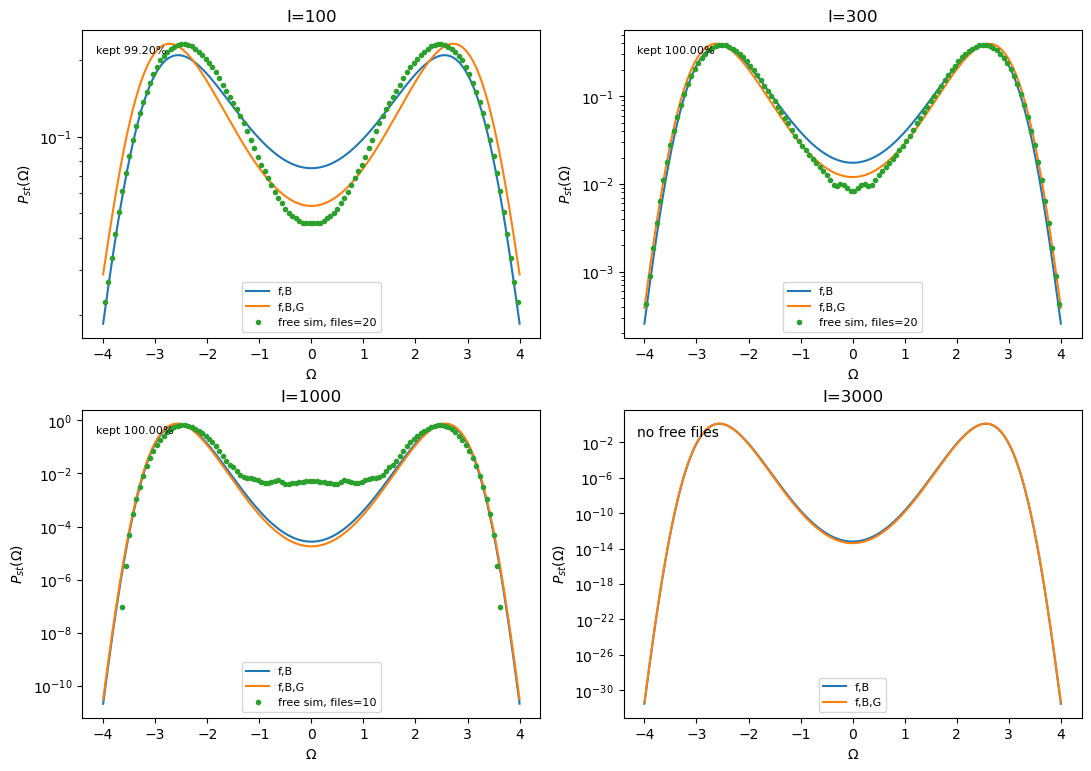

In [7]:
# 5. compact PDF prediction with particle-number scaling
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.ndimage import gaussian_filter1d

# -------------------- settings --------------------
# run_traj.py currently uses 5000 active particles; older free files may not save this metadata.
FREE_N_PTCL = 5000
# run_wperturb_ens.py saves taubar/B scaled to N_PTCL_TARGET=10000.
LANDSCAPE_N_PTCL = 10000
# G_summary computed above is from per-particle quench correlations in run_wperturb_ens.py.
G_SUMMARY_UNITS = 'per_particle'  # 'per_particle' or 'landscape_total'

free_data_dir = 'data/free/21/'
I_list_pdf = [100, 300, 1000, 3000]#, 10000, 30000, 100000]
n_seed_free = 20
smooth_sigma_bins = 1.0
symmetrize_measured_pdf = True

poly_tau_degree = 5   # odd
poly_B_degree = 4     # even
poly_G_degree = 5     # odd
use_G_from_summary = True
plot_current_balance = False


def fit_parity_polynomial(omega, values, parity, max_degree, force_zero=False):
    omega = np.asarray(omega, dtype=float)
    values = np.asarray(values, dtype=float)
    mask = np.isfinite(omega) & np.isfinite(values)
    omega = omega[mask]
    values = values[mask].copy()
    order = np.argsort(omega)
    omega = omega[order]
    values = values[order]

    if force_zero:
        values[np.abs(omega) < 1e-12] = 0.0

    if parity == 'odd':
        powers = np.arange(1, max_degree + 1, 2)
    elif parity == 'even':
        powers = np.arange(0, max_degree + 1, 2)
    else:
        raise ValueError("parity must be 'odd' or 'even'.")

    powers = powers[:max(1, min(len(powers), len(omega)))]
    basis = np.vstack([omega**p for p in powers]).T
    coeff, *_ = np.linalg.lstsq(basis, values, rcond=None)

    def fun(x):
        x = np.asarray(x, dtype=float)
        out = np.zeros_like(x, dtype=float)
        for c, p in zip(coeff, powers):
            out += c * x**p
        return out

    return fun, powers, coeff


def collect_G_grid(omega_grid, G_summary, use_G=True):
    omega_grid = np.asarray(omega_grid, dtype=float)
    G_grid = np.zeros_like(omega_grid)
    G_err = np.full_like(omega_grid, np.nan, dtype=float)

    if (not use_G) or G_summary is None:
        return G_grid, G_err, 'G=0'

    for i, omega in enumerate(omega_grid):
        block = None
        for key, value in G_summary.items():
            if abs(float(key) - float(omega)) < 1e-12:
                block = value
                break
        if not block:
            continue

        vals, errs = [], []
        for entry in block.values():
            if 'G_plateau' in entry:
                vals.append(float(entry['G_plateau']))
                errs.append(float(entry.get('G_plateau_sem', np.nan)))
        if len(vals) == 0:
            continue

        vals = np.asarray(vals, dtype=float)
        errs = np.asarray(errs, dtype=float)
        good_err = np.isfinite(errs) & (errs > 0)
        if np.any(good_err):
            weights = np.ones_like(vals)
            weights[good_err] = 1.0 / errs[good_err]**2
            G_grid[i] = np.sum(weights * vals) / np.sum(weights)
            G_err[i] = np.sqrt(1.0 / np.sum(weights[good_err]))
        else:
            G_grid[i] = np.mean(vals)
            G_err[i] = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan

    G_grid[np.abs(omega_grid) < 1e-12] = 0.0
    return G_grid, G_err, 'G from G_summary plateaus'


def load_measured_pdf(I, directory, bins, n_seed=20, smooth_sigma_bins=1.0, symmetrize=True):
    count_hist = np.zeros(len(bins) - 1, dtype=float)
    n_loaded = 0
    n_total = 0
    n_kept = 0
    n_ptcl_seen = []

    for seed in range(n_seed):
        state = os.path.join(os.getcwd(), directory, f'{I}seed{seed}.npz')
        if not os.path.exists(state):
            continue

        with np.load(state) as data:
            omega_traj = np.asarray(data['omega_traj'], dtype=float).ravel()
            if 'N_ptcl' in data:
                n_ptcl_seen.append(int(data['N_ptcl']))

        omega_traj = omega_traj[np.isfinite(omega_traj)]
        n_total += len(omega_traj)
        inside = (omega_traj >= bins[0]) & (omega_traj <= bins[-1])
        n_kept += int(np.sum(inside))
        count_hist += np.histogram(omega_traj[inside], bins=bins)[0]
        n_loaded += 1

    if n_loaded == 0 or np.sum(count_hist) == 0:
        return None, None, 0, np.nan, n_ptcl_seen

    widths = np.diff(bins)
    centers = 0.5 * (bins[:-1] + bins[1:])
    if symmetrize:
        if not np.allclose(bins, -bins[::-1]):
            raise ValueError('symmetrized PDF needs bins symmetric around zero.')
        count_hist = 0.5 * (count_hist + count_hist[::-1])

    P = count_hist / np.sum(count_hist * widths)
    if smooth_sigma_bins is not None and smooth_sigma_bins > 0:
        P = gaussian_filter1d(P, sigma=smooth_sigma_bins, mode='nearest')
        if symmetrize:
            P = 0.5 * (P + P[::-1])
        P = np.clip(P, 0.0, None)
        P /= np.sum(P * widths)

    kept_fraction = n_kept / n_total if n_total else np.nan
    return centers, P, n_loaded, kept_fraction, n_ptcl_seen


def predict_pdf(omega_eval, I, tau_fun, B_fun, G_fun=None):
    xs = np.sort(np.asarray(omega_eval, dtype=float))
    tau = np.asarray(tau_fun(xs), dtype=float)
    B = np.asarray(B_fun(xs), dtype=float)
    G = np.zeros_like(xs) if G_fun is None else np.asarray(G_fun(xs), dtype=float)

    B_floor = max(1e-12, 1e-8 * np.nanmax(np.abs(B)))
    B = np.maximum(B, B_floor)

    # Maes convention with measured tau=<total torque>=-f:
    # d log P / dOmega = (I*tau - G) / B.
    logP_slope = (I * tau - G) / B
    logP = cumulative_trapezoid(logP_slope, xs, initial=0.0)
    logP -= np.interp(0.0, xs, logP)
    logP -= np.nanmax(logP)

    P = np.exp(logP)
    P /= np.trapz(P, xs)
    psi = -logP
    psi -= np.nanmin(psi)
    return xs, P, psi, logP_slope


def current_components(omega, P, I, tau_fun, B_fun, G_fun=None):
    omega = np.asarray(omega, dtype=float)
    P = np.asarray(P, dtype=float)
    tau = np.asarray(tau_fun(omega), dtype=float)
    B = np.asarray(B_fun(omega), dtype=float)
    G = np.zeros_like(omega) if G_fun is None else np.asarray(G_fun(omega), dtype=float)
    dP = np.gradient(P, omega, edge_order=2 if len(omega) > 2 else 1)
    J_tau = I * tau * P
    J_G = -G * P
    J_B = -B * dP
    return J_tau, J_G, J_B, J_tau + J_G + J_B


# -------------------- scale forced-landscape data to free-run particle number --------------------
omega_data = np.asarray(omega_list, dtype=float)
N_scale = FREE_N_PTCL / LANDSCAPE_N_PTCL

tau_landscape = np.asarray(tau_avg, dtype=float)          # total torque for LANDSCAPE_N_PTCL
B_landscape = np.asarray(Dr_int, dtype=float)             # total torque-noise integral for LANDSCAPE_N_PTCL
B_err_landscape = np.asarray(Dr_err, dtype=float) if 'Dr_err' in globals() else np.full_like(B_landscape, np.nan)

tau_data = tau_landscape * N_scale
B_data = B_landscape * N_scale
B_err_data = B_err_landscape * N_scale

G_raw, G_raw_err, G_label = collect_G_grid(
    omega_data,
    G_summary if 'G_summary' in globals() else None,
    use_G=use_G_from_summary,
)
if G_SUMMARY_UNITS == 'per_particle':
    G_data = G_raw * FREE_N_PTCL
    G_err_data = G_raw_err * FREE_N_PTCL
    G_label += f' scaled by N_free={FREE_N_PTCL}'
elif G_SUMMARY_UNITS == 'landscape_total':
    G_data = G_raw * N_scale
    G_err_data = G_raw_err * N_scale
    G_label += f' scaled by N_free/N_landscape={N_scale:g}'
else:
    raise ValueError("G_SUMMARY_UNITS must be 'per_particle' or 'landscape_total'.")

print(f'PDF scaling: free N={FREE_N_PTCL}, landscape N={LANDSCAPE_N_PTCL}, N_scale={N_scale:g}')
print('tau and B are scaled by N_scale; per-particle G is scaled by N_free.')

# -------------------- fit compact parity-respecting landscapes --------------------
tau_raw_fun, tau_powers, tau_coeff = fit_parity_polynomial(
    omega_data, tau_data, 'odd', poly_tau_degree, force_zero=True
)
B_raw_fun, B_powers, B_coeff = fit_parity_polynomial(
    omega_data, B_data, 'even', poly_B_degree
)
G_raw_fun, G_powers, G_coeff = fit_parity_polynomial(
    omega_data, G_data, 'odd', poly_G_degree, force_zero=True
)

positive_B = B_data[np.isfinite(B_data) & (B_data > 0)]
B_floor = max(1e-12, 0.05 * np.min(positive_B))

def tau_fun(x):
    return tau_raw_fun(x)

def B_fun(x):
    return np.maximum(B_raw_fun(x), B_floor)

def G_fun(x):
    x = np.asarray(x, dtype=float)
    return G_raw_fun(x) if use_G_from_summary else np.zeros_like(x)

omega_max = np.nanmax(np.abs(omega_data[np.isfinite(omega_data)]))
omega_eval = np.linspace(-omega_max, omega_max, 2001)
omega_fit = np.linspace(0.0, omega_max, 500)
bins = np.linspace(-omega_max, omega_max, 121)

print('tau powers/coeff:', tau_powers.tolist(), tau_coeff)
print('B powers/coeff/floor:', B_powers.tolist(), B_coeff, B_floor)
print('G powers/coeff:', G_powers.tolist(), G_coeff, G_label)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
axes[0].plot(omega_fit, tau_fun(omega_fit), label='scaled odd fit')
axes[0].plot(omega_data, tau_data, 'o', label='scaled data')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xlabel(r'$\Omega$')
axes[0].set_ylabel(r'$\langle\tau\rangle$ for free N')
axes[0].legend(fontsize=8)

axes[1].plot(omega_fit, B_raw_fun(omega_fit), '--', alpha=0.5, label='raw even fit')
axes[1].plot(omega_fit, B_fun(omega_fit), label='clipped fit')
axes[1].errorbar(omega_data, B_data, yerr=B_err_data, fmt='o', label='scaled data')
axes[1].axhline(B_floor, color='k', lw=0.8, alpha=0.5)
axes[1].set_xlabel(r'$\Omega$')
axes[1].set_ylabel(r'$B$ for free N')
axes[1].legend(fontsize=8)

axes[2].plot(omega_fit, G_fun(omega_fit), label='scaled odd fit')
axes[2].errorbar(omega_data, G_data, yerr=G_err_data, fmt='o', label=G_label)
axes[2].axhline(0, color='k', lw=0.8)
axes[2].set_xlabel(r'$\Omega$')
axes[2].set_ylabel(r'$G$ for free N')
axes[2].legend(fontsize=8)
plt.show()

# -------------------- predict and compare PDFs --------------------
ncols = 2
nrows = math.ceil(len(I_list_pdf) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 3.8 * nrows), squeeze=False, constrained_layout=True)
for ax in axes.ravel():
    ax.set_visible(False)

pdf_results = {}
for ax, I in zip(axes.ravel(), I_list_pdf):
    ax.set_visible(True)
    omega_pdf, P_fB, psi_fB, _ = predict_pdf(omega_eval, I, tau_fun, B_fun, G_fun=None)
    _, P_fBG, psi_fBG, _ = predict_pdf(omega_eval, I, tau_fun, B_fun, G_fun=G_fun)
    centers_meas, P_meas, n_loaded, kept_fraction, n_ptcl_seen = load_measured_pdf(
        I,
        free_data_dir,
        bins,
        n_seed=n_seed_free,
        smooth_sigma_bins=smooth_sigma_bins,
        symmetrize=symmetrize_measured_pdf,
    )

    pdf_results[I] = {
        'omega': omega_pdf,
        'P_fB': P_fB,
        'P_fBG': P_fBG,
        'omega_meas': centers_meas,
        'P_meas': P_meas,
        'n_loaded': n_loaded,
        'kept_fraction': kept_fraction,
        'free_N_seen': sorted(set(n_ptcl_seen)),
    }

    ax.plot(omega_pdf, P_fB, label='f,B')
    ax.plot(omega_pdf, P_fBG, label='f,B,G')
    if n_loaded > 0:
        ax.plot(centers_meas, P_meas, 'o', ms=3, label=f'free sim, files={n_loaded}')
        ax.text(0.03, 0.95, f'kept {kept_fraction:.2%}', transform=ax.transAxes, va='top', fontsize=8)
        if n_ptcl_seen and any(n != FREE_N_PTCL for n in n_ptcl_seen):
            ax.text(0.03, 0.86, f'N in files: {sorted(set(n_ptcl_seen))}', transform=ax.transAxes, va='top', fontsize=8, color='crimson')
    else:
        ax.text(0.03, 0.95, 'no free files', transform=ax.transAxes, va='top')
    ax.set_title(f'I={I}')
    ax.set_xlabel(r'$\Omega$')
    ax.set_ylabel(r'$P_{st}(\Omega)$')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
plt.show()

if plot_current_balance:
    for I, result in pdf_results.items():
        if result['P_meas'] is None:
            continue
        J_tau, J_G, J_B, J_total = current_components(
            result['omega_meas'], result['P_meas'], I, tau_fun, B_fun, G_fun
        )
        plt.figure(figsize=(5, 3.5))
        plt.axhline(0, color='k', lw=0.8)
        plt.plot(result['omega_meas'], J_tau, label=r'$I\tau P$')
        plt.plot(result['omega_meas'], J_G, label=r'$-GP$')
        plt.plot(result['omega_meas'], J_B, label=r'$-B\partial_\Omega P$')
        plt.plot(result['omega_meas'], J_total, '--', label=r'$J_{tot}$')
        plt.title(f'I={I} measured-P current balance')
        plt.xlabel(r'$\Omega$')
        plt.ylabel('current components')
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
